<b>¡Hola Aron!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np
from statsmodels.stats.proportion import proportions_ztest


# Correcciones

In [2]:
df = pd.read_csv('/datasets/logs_exp_us.csv', sep = '\t')

Eliminamos un separador que hacia practicamente imposible de leer los datos

In [3]:
print(df.head())

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248


<div class="alert alert-block alert-success">
<b>Celda [3]</b> <a class="tocSkip"></a><br>
Has cargado y mostrado correctamente las primeras filas del conjunto de datos. Esto es crucial para obtener una visión inicial de la estructura y contenido del DataFrame, lo cual te ayudará a planificar tus siguientes pasos en el análisis.
</div>


In [4]:
df.info

<bound method DataFrame.info of                       EventName         DeviceIDHash  EventTimestamp  ExpId
0              MainScreenAppear  4575588528974610257      1564029816    246
1              MainScreenAppear  7416695313311560658      1564053102    246
2       PaymentScreenSuccessful  3518123091307005509      1564054127    248
3              CartScreenAppear  3518123091307005509      1564054127    248
4       PaymentScreenSuccessful  6217807653094995999      1564055322    248
...                         ...                  ...             ...    ...
244121         MainScreenAppear  4599628364049201812      1565212345    247
244122         MainScreenAppear  5849806612437486590      1565212439    246
244123         MainScreenAppear  5746969938801999050      1565212483    246
244124         MainScreenAppear  5746969938801999050      1565212498    246
244125       OffersScreenAppear  5746969938801999050      1565212517    246

[244126 rows x 4 columns]>

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None


<div class="alert alert-block alert-success">
<b>Celda [5]</b> <a class="tocSkip"></a><br>
El uso del método <code>info()</code> ha sido adecuado para obtener una descripción general del DataFrame. Esto es esencial para confirmar la ausencia de valores nulos y verificar los tipos de datos, lo que te permitirá manejar correctamente el conjunto de datos en análisis posteriores.
</div>


# Reenombramos las columnas a nombres mas sencillos de trabajar y mas limpios

In [6]:
df.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'device_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
}, inplace=True)

<div class="alert alert-block alert-success">
<b>Celda [6]</b> <a class="tocSkip"></a><br>
Has renombrado las columnas para mejorar la consistencia y legibilidad del DataFrame, lo cual es una buena práctica para facilitar el trabajo con los datos. 
</div>


In [7]:
print(df.head())

                event_name            device_id  event_timestamp  exp_id
0         MainScreenAppear  4575588528974610257       1564029816     246
1         MainScreenAppear  7416695313311560658       1564053102     246
2  PaymentScreenSuccessful  3518123091307005509       1564054127     248
3         CartScreenAppear  3518123091307005509       1564054127     248
4  PaymentScreenSuccessful  6217807653094995999       1564055322     248


In [8]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
event_name         0
device_id          0
event_timestamp    0
exp_id             0
dtype: int64


<div class="alert alert-block alert-success">
<b>Celda [8]</b> <a class="tocSkip"></a><br>
Has verificado correctamente la ausencia de valores nulos en el conjunto de datos. Asegurarte de que no hay valores faltantes es un paso importante antes de realizar cualquier análisis, ya que garantiza la integridad de los resultados.
</div>


In [9]:
df['data_time'] = pd.to_datetime(df['event_timestamp'], unit='s')
df['event_date'] = df['data_time'].dt.floor('1D')

In [10]:
df.sample(10)

,event_name,device_id,event_timestamp,exp_id,data_time,event_date
193564,MainScreenAppear,4330273175185297210,1565094520,247,2019-08-06 12:28:40,2019-08-06
85237,MainScreenAppear,6567588976245816164,1564826957,247,2019-08-03 10:09:17,2019-08-03
211588,PaymentScreenSuccessful,8309980273750324949,1565123191,246,2019-08-06 20:26:31,2019-08-06
70959,MainScreenAppear,1110896155120934852,1564773265,247,2019-08-02 19:14:25,2019-08-02
99767,OffersScreenAppear,294839098209826717,1564849275,246,2019-08-03 16:21:15,2019-08-03
26853,MainScreenAppear,5375697691143223385,1564673977,247,2019-08-01 15:39:37,2019-08-01
35259,MainScreenAppear,3882145009739574347,1564686459,248,2019-08-01 19:07:39,2019-08-01
50053,MainScreenAppear,3521696259961091617,1564738312,248,2019-08-02 09:31:52,2019-08-02
62355,MainScreenAppear,3722204315779155652,1564758524,247,2019-08-02 15:08:44,2019-08-02
194726,PaymentScreenSuccessful,4616785310672126142,1565096727,248,2019-08-06 13:05:27,2019-08-06


Convertimos la columna de event_timestamp a datatime para poder trabajar mejor con ella

# creando una columna de fecha y hora. solo de fechas

In [11]:
df.head()

,event_name,device_id,event_timestamp,exp_id,data_time,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


#  ¿Cuántos eventos hay en los registros?

In [12]:
total_eventos = len(df)
print(f"Número total de eventos: {total_eventos}")

Número total de eventos: 244126


<div class="alert alert-block alert-success">
<b>Celda [12]</b> <a class="tocSkip"></a><br>
Has calculado correctamente el número total de eventos, lo cual es una métrica fundamental para tener una idea clara del volumen de datos que estás manejando. Esto te ayudará a contextualizar tus análisis posteriores.
</div>


# ¿Cuántos usuarios hay en los registros?

In [13]:
usuarios_unicos = df['device_id'].nunique()
print(f"Número total de usuarios únicos: {usuarios_unicos}")

Número total de usuarios únicos: 7551


# ¿Cuál es el promedio de eventos por usuario?

In [14]:
promedio_eventos_por_usuario = total_eventos / usuarios_unicos
print(f"Promedio de eventos por usuario: {promedio_eventos_por_usuario:.2f}")

Promedio de eventos por usuario: 32.33


<div class="alert alert-block alert-success">
<b>Celda [14]</b> <a class="tocSkip"></a><br>
El cálculo del promedio de eventos por usuario es relevante para entender el comportamiento de los usuarios en la aplicación. Esta métrica te proporciona una perspectiva sobre la interacción promedio de los usuarios, lo cual es valioso para el análisis del uso de la aplicación.
</div>


# fecha minima y maxima

In [15]:
fecha_min = df['data_time'].min()
fecha_max = df['data_time'].max()

print(f"Fecha mínima: {fecha_min}")
print(f"Fecha máxima: {fecha_max}")

Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17


# eventos por dia

In [16]:
eventos_por_fecha = df.groupby('event_date').size()
eventos_por_fecha

event_date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
dtype: int64

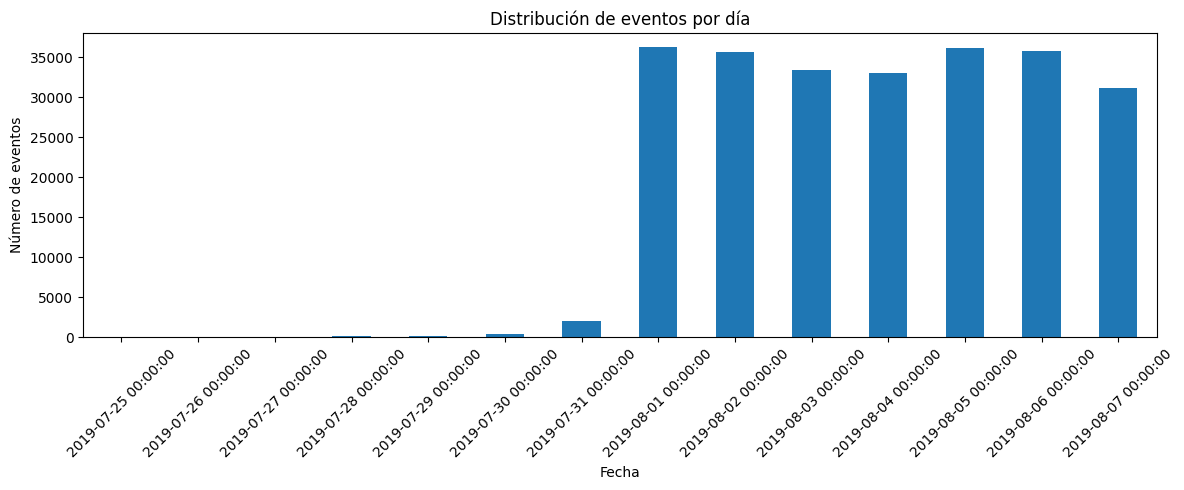

In [17]:
plt.figure(figsize=(12, 5))
eventos_por_fecha.plot(kind='bar')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.title('Distribución de eventos por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Celda [17]</b> <a class="tocSkip"></a><br>
La visualización de la distribución de eventos por día está bien lograda y es clara. Este tipo de gráfico es útil para identificar patrones temporales en el uso de la aplicación, lo que puede ayudarte a detectar días con actividad inusual o tendencias generales de uso.
</div>


conclusion del grafico: tenemos un crecimiento exponencial y que mantuvo la cantidad de acciones en la pagina web apartir del primero de agosto hasta el 7 de agosto se mantuvo constante la cantidad de acciones pero por alguna razon no tuvo mas creciemiento que ese ni disminucion que puede ser una buena o mala señal no parece un crecimiento organico como si fuera una escalera o con picos solo exploto y se mantuvo sin cambios que sean de ayuda para la explicacion 

In [18]:
df['event_hour'] = df['data_time'].dt.hour

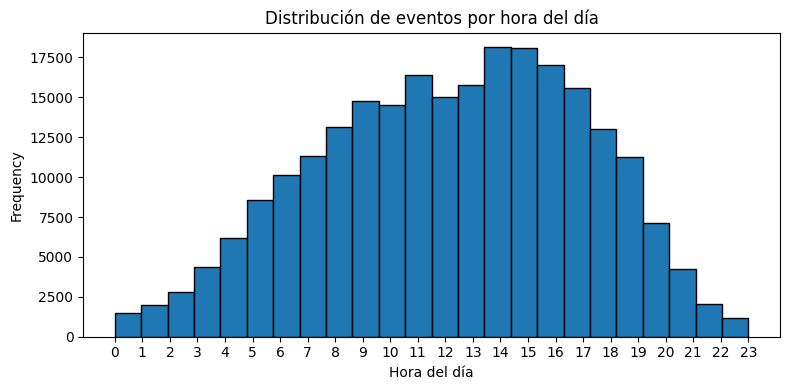

In [19]:
plt.figure(figsize=(8, 4))
df['event_hour'].plot.hist(bins=24, edgecolor='black')
plt.xlabel('Hora del día')
plt.title('Distribución de eventos por hora del día')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Celda [19]</b> <a class="tocSkip"></a><br>
La visualización de la distribución de eventos por hora del día está bien realizada. Este análisis puede ofrecerte información valiosa sobre los momentos de mayor actividad en la aplicación, lo cual es crucial para optimizar recursos y mejorar la experiencia del usuario.
</div>


Conclusion del grafico: durante el dia es obvio que durante el medio dia y hasta las 5 pm es donde mayor cantidad de acciones o eventos hay 

# eliminando datos antiguos

In [20]:
df = df[df['data_time'] > pd.to_datetime('2019-08-01')]
df.head()

,event_name,device_id,event_timestamp,exp_id,data_time,event_date,event_hour
2828,Tutorial,3737462046622621720,1564618048,246,2019-08-01 00:07:28,2019-08-01,0
2829,MainScreenAppear,3737462046622621720,1564618080,246,2019-08-01 00:08:00,2019-08-01,0
2830,MainScreenAppear,3737462046622621720,1564618135,246,2019-08-01 00:08:55,2019-08-01,0
2831,OffersScreenAppear,3737462046622621720,1564618138,246,2019-08-01 00:08:58,2019-08-01,0
2832,MainScreenAppear,1433840883824088890,1564618139,247,2019-08-01 00:08:59,2019-08-01,0


In [21]:
total_eventos = len(df)
print(f"Número total de eventos: {total_eventos}")

Número total de eventos: 241298


Se pierden muy pocos eventos no parece significativo para el analisis y siguen existiendo los 3 grupos experimentales

# Frecuencia total de cada tipo de evento, ordenada

In [22]:
frecuencia_eventos = df['event_name'].value_counts()
print("Frecuencia total de eventos:")
print(frecuencia_eventos)

Frecuencia total de eventos:
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: event_name, dtype: int64


usuarios que hicieron almenos una accion 

In [23]:
usuarios_por_evento = df.groupby('event_name')['device_id'].nunique().sort_values(ascending=False)
print("\nUsuarios únicos por evento:")
print(usuarios_por_evento)


Usuarios únicos por evento:
event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: device_id, dtype: int64


LOS DATOS REVISADOS DEMUESTRA QUE SON UNA SECUENCIA DE ACCIONES  aunque de todas las acciones la mas importante son la de paymentscreen successful que practicamente es que se logro una venta aunque comparado con el filtrado anterior se nota cuantos clientes se pasean por la pagina constantemente antes de concretar una compra y cuantos terminan no comprando y solo tuvimos durente ese periodo de tiempo 3539 ventas en la pagina

el orden son Main screen- offersscreen- cartscreen y paymen screen como secuencia y el tutorial debe estar como otra ruta o alternativo no obligatorio en la pagina web como un extra que existe para ayudar pero no es una parte obligatorio por el que se tenga que navegar en la pagina

# embudo

In [24]:
secuencia_embudo = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

In [25]:
usuarios_eventos = df.groupby('device_id')['event_name'].unique()

In [26]:
usuarios_por_etapa = {
    evento: usuarios_eventos[usuarios_eventos.apply(lambda x: evento in x)].index
    for evento in secuencia_embudo
}

In [27]:
caidas = []
etapas = []

for i in range(len(secuencia_embudo) - 1):
    etapa_actual = secuencia_embudo[i]
    etapa_siguiente = secuencia_embudo[i + 1]

    usuarios_actual = set(usuarios_por_etapa[etapa_actual])
    usuarios_siguiente = set(usuarios_por_etapa[etapa_siguiente])

    tasa_conversion = len(usuarios_siguiente & usuarios_actual) / len(usuarios_actual)
    caida = 1 - tasa_conversion

    etapas.append(f"{etapa_actual} → {etapa_siguiente}")
    caidas.append(caida)

In [28]:
indice_mayor_caida = caidas.index(max(caidas))
etapa_mayor_caida = etapas[indice_mayor_caida]
porcentaje_caida = caidas[indice_mayor_caida] * 100

print(f"La mayor pérdida de usuarios ocurre en: {etapa_mayor_caida}")
print(f"Porcentaje de pérdida: {porcentaje_caida:.2f}%")

La mayor pérdida de usuarios ocurre en: MainScreenAppear → OffersScreenAppear
Porcentaje de pérdida: 39.59%


<div class="alert alert-block alert-warning">
<b>Celda [28]</b> <a class="tocSkip"></a><br>
Has identificado correctamente la mayor pérdida de usuarios en el embudo de conversión, específicamente entre 'MainScreenAppear' y 'OffersScreenAppear'. Sería beneficioso investigar las causas de esta caída para entender mejor el comportamiento de los usuarios y proponer mejoras en el proceso de conversión.
</div>


Conclusion: como era predecible la etapa de mainscreen a offers es dodne se pierden mas usuarios y eventos 

# porcentaje de principio a final

In [29]:
usuarios_completos = usuarios_eventos[
    usuarios_eventos.apply(lambda eventos: all(e in eventos for e in secuencia_embudo))
].index

In [30]:
usuarios_totales = df['device_id'].nunique()

In [31]:
porcentaje_completos = len(usuarios_completos) / usuarios_totales * 100

print(f"{porcentaje_completos:.2f}% de los usuarios completaron todo el viaje desde su primer evento hasta el pago.")

45.51% de los usuarios completaron todo el viaje desde su primer evento hasta el pago.


<div class="alert alert-block alert-success">
<b>Celda [31]</b> <a class="tocSkip"></a><br>
El cálculo del porcentaje de usuarios que completaron todo el embudo de conversión es una métrica clave para evaluar el rendimiento de la aplicación. Este dato te proporciona una visión clara de cuántos usuarios logran completar el proceso desde el inicio hasta el pago.
</div>


un 45% de los usuarios unicos completaron la secuencia hasta concluir en una compra considero que es un muy buen % en mi opinion.

# cuantos usuarios hay en cada grupo

In [32]:
usuarios_por_grupo = df.groupby('exp_id')['device_id'].nunique().sort_index()

print("Usuarios únicos por grupo experimental:")
print(usuarios_por_grupo)

Usuarios únicos por grupo experimental:
exp_id
246    2484
247    2513
248    2537
Name: device_id, dtype: int64


Las diferencias a primera impresion no parecen ser muy grandes

In [33]:
df_controles = df[df['exp_id'].isin([246, 247])]

In [34]:
eventos_por_usuario = df_controles.groupby(['exp_id', 'device_id']).size().reset_index(name='event_count')

In [35]:
grupo_246 = eventos_por_usuario[eventos_por_usuario['exp_id'] == 246]['event_count']
grupo_247 = eventos_por_usuario[eventos_por_usuario['exp_id'] == 247]['event_count']

In [36]:
stat, p_valor = mannwhitneyu(grupo_246, grupo_247, alternative='two-sided')
print(f"Estadístico U: {stat}")
print(f"Valor p: {p_valor:.5f}")

if p_valor < 0.05:
    print("Diferencia estadísticamente significativa entre los grupos 246 y 247.")
else:
    print("NO hay diferencia estadísticamente significativa entre los grupos 246 y 247.")

Estadístico U: 3129241.0
Valor p: 0.87384
NO hay diferencia estadísticamente significativa entre los grupos 246 y 247.


<div class="alert alert-block alert-success">
<b>Celda [36]</b> <a class="tocSkip"></a><br>
Has aplicado correctamente la prueba de Mann-Whitney para evaluar las diferencias entre los grupos experimentales 246 y 247. La interpretación de los resultados, indicando la ausencia de diferencias estadísticamente significativas, es adecuada y bien fundamentada.
</div>


Comente un poco antes de que no notaba una diferencia significativa entre los diferentes grupos y parece indicar la prueba que es verdad no hay grandes diferencias

El evento mas popular de cada control

antes de comenzar el codigo comoa ntes ya lo habiamos hablado el evento mas popular probablemente sera el mainscreen ya que por mucho era el que mas eventos tenia en general y creo que sera similar y tampoco creo que existan diferencias significativas entre uno y otro de los controles

In [37]:
evento_mas_popular = df['event_name'].value_counts().idxmax()
print(evento_mas_popular)

MainScreenAppear


funcion para la prueba

In [38]:
def comparar_proporcion_usuarios(evento, grupo1, grupo2):
    usuarios_g1 = df[(df['exp_id'] == grupo1) & (df['event_name'] == evento)]['device_id'].nunique()
    usuarios_g2 = df[(df['exp_id'] == grupo2) & (df['event_name'] == evento)]['device_id'].nunique()

    total_g1 = df[df['exp_id'] == grupo1]['device_id'].nunique()
    total_g2 = df[df['exp_id'] == grupo2]['device_id'].nunique()

    count = np.array([usuarios_g1, usuarios_g2])
    nobs = np.array([total_g1, total_g2])

    stat, pval = proportions_ztest(count, nobs)
    
    return {
        'evento': evento,
        'grupo1_proporcion': usuarios_g1 / total_g1,
        'grupo2_proporcion': usuarios_g2 / total_g2,
        'p_valor': pval
    }

In [39]:
resultado_evento_popular = comparar_proporcion_usuarios(evento_mas_popular, 246, 247)
print("Evento más popular:", resultado_evento_popular)

Evento más popular: {'evento': 'MainScreenAppear', 'grupo1_proporcion': 0.9863123993558777, 'grupo2_proporcion': 0.9852765618782332, 'p_valor': 0.7570597232046099}


In [40]:
eventos = df['event_name'].unique()
resultados = [comparar_proporcion_usuarios(e, 246, 247) for e in eventos]

In [41]:
df_resultados = pd.DataFrame(resultados).sort_values('p_valor')
print("\nComparación entre todos los eventos:\n")
print(df_resultados)


Comparación entre todos los eventos:

                    evento  grupo1_proporcion  grupo2_proporcion   p_valor
4  PaymentScreenSuccessful           0.483092           0.460804  0.114567
3         CartScreenAppear           0.509662           0.492638  0.228834
2       OffersScreenAppear           0.620773           0.604855  0.248095
1         MainScreenAppear           0.986312           0.985277  0.757060
0                 Tutorial           0.111916           0.112614  0.937700


como comente antes no noto diferencias relevante o significante y esto puede indicar que la separacion de grupos se hizo correctamente

comparando con el grupo excluyente el 248 

no tenia muchas ideas de como hacer lo de los grupos o fuentes alternas 

In [42]:
def comparar_evento(df, evento, grupo1, grupo2):
    usuarios_g1 = df[(df['exp_id'] == grupo1) & (df['event_name'] == evento)]['device_id'].nunique()
    usuarios_g2 = df[(df['exp_id'] == grupo2) & (df['event_name'] == evento)]['device_id'].nunique()
    total_g1 = df[df['exp_id'] == grupo1]['device_id'].nunique()
    total_g2 = df[df['exp_id'] == grupo2]['device_id'].nunique()
    count = np.array([usuarios_g1, usuarios_g2])
    nobs = np.array([total_g1, total_g2])
    stat, pval = proportions_ztest(count, nobs)
    return {
        'evento': evento,
        'grupo1_proporcion': usuarios_g1 / total_g1,
        'grupo2_proporcion': usuarios_g2 / total_g2,
        'p_valor': pval
    }

In [43]:
eventos_unicos = df['event_name'].unique()


In [45]:
df['grupo_control_combinado'] = df['exp_id'].replace({246: 'control', 247: 'control', 248: 'test'})

/tmp/ipykernel_221/1332233662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grupo_control_combinado'] = df['exp_id'].replace({246: 'control', 247: 'control', 248: 'test'})


<div class="alert alert-block alert-warning">
<b>Celda [45]</b> <a class="tocSkip"></a><br>
Has creado una columna para distinguir entre los grupos de control y el grupo de prueba. No obstante, el mensaje de advertencia sugiere que podrías estar modificando una vista del DataFrame. Para evitar posibles problemas, considera usar <code>df.loc[:, 'grupo_control_combinado'] = ...</code>, lo cual es una práctica recomendada para asegurar que estás trabajando con una copia del DataFrame.
</div>


In [46]:
resultados_vs_246 = [comparar_evento(df, evento, 248, 246) for evento in eventos]
resultados_vs_247 = [comparar_evento(df, evento, 248, 247) for evento in eventos]
resultados_vs_control_combinado = [comparar_evento(df[df['exp_id'] != 247], evento, 248, 246) for evento in eventos]

In [47]:
df_vs_246 = pd.DataFrame(resultados_vs_246).sort_values('p_valor')
df_vs_247 = pd.DataFrame(resultados_vs_247).sort_values('p_valor')
df_vs_control_comb = pd.DataFrame(resultados_vs_control_combinado).sort_values('p_valor')


In [48]:
print("Grupo 248 vs 246:\n", df_vs_246)
print("\nGrupo 248 vs 247:\n", df_vs_247)
print("\nGrupo 248 vs (246 + 247 combinados):\n", df_vs_control_comb)

Grupo 248 vs 246:
                     evento  grupo1_proporcion  grupo2_proporcion   p_valor
3         CartScreenAppear           0.484825           0.509662  0.078429
2       OffersScreenAppear           0.603469           0.620773  0.208362
4  PaymentScreenSuccessful           0.465510           0.483092  0.212255
1         MainScreenAppear           0.982657           0.986312  0.294972
0                 Tutorial           0.109972           0.111916  0.826429

Grupo 248 vs 247:
                     evento  grupo1_proporcion  grupo2_proporcion   p_valor
1         MainScreenAppear           0.982657           0.985277  0.458705
3         CartScreenAppear           0.484825           0.492638  0.578620
4  PaymentScreenSuccessful           0.465510           0.460804  0.737342
0                 Tutorial           0.109972           0.112614  0.765324
2       OffersScreenAppear           0.603469           0.604855  0.919782

Grupo 248 vs (246 + 247 combinados):
                     ev

si lo que entiendo es correcto el grupo 248 solo tiene un p valor mayor en el tutorial o vs el grupo 247  donde es significantemente mayor a diferencia de las otras 2 proporciones solo contra el grupo 247 el cambio a sido positivo

¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente?

usamos nivel de significancia de 0.05

Calcula cuántas pruebas de hipótesis estadísticas has realizado.

si no me equvico hicimos 3 con las 3 comparativas de los grupos 248-246 y 247

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Aron! A lo largo del proyecto has demostrado competencias sólidas en varias áreas clave:<br><br>
• Carga y exploración inicial de datos bien ejecutada, permitiéndote comprender la estructura básica del conjunto de datos.<br>
• Renombrado de columnas para mejorar la legibilidad, lo cual facilita el manejo de los datos.<br>
• Verificación de valores nulos realizada correctamente, asegurando la integridad de los datos.<br>
• Transformaciones temporales bien implementadas, que permiten un análisis más detallado de los datos temporales.<br>
• Cálculo de métricas clave como el número total de eventos y usuarios únicos, proporcionando una visión general del volumen de datos.<br>
• Visualización clara y efectiva de la distribución de eventos por día y hora, ayudando a identificar patrones de uso.<br>
• Identificación precisa de la mayor caída en el embudo de conversión, lo que es crucial para mejorar la retención de usuarios.<br>
• Uso correcto de pruebas estadísticas para comparar grupos experimentales, asegurando la validez de las conclusiones.<br>
• Interpretación adecuada de resultados estadísticos, lo que demuestra una comprensión clara de los análisis realizados.<br>
• Implementación de funciones para comparar proporciones entre grupos, lo que añade flexibilidad y profundidad al análisis.<br>
¡Felicidades!
</div>
